In [1]:
from sleep_stage_prediction.data import load_dreamt, Workflow
from sleep_stage_prediction.models import ConvolutionalClassifier
import numpy as np 
import torch 
import torch.nn as nn 

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
frequency = 64 
seed = 42
nb_patients = 25 
workflow = Workflow.CENTRALIZED
lr = 0.001 
epochs = 50
batch_size = 128
momentum = 0.9 

X_train, X_test, y_train, y_test = load_dreamt(
        nb_patients, workflow=workflow, frequency=frequency, seed=seed
    )


In [2]:
from sleep_stage_prediction.data import DreamtDataset
from torch.utils.data import DataLoader

in_samples = np.random.choice(X_train.shape[0], replace=False, size=X_train.shape[0] // 2 )
mask_in = np.zeros(X_train.shape[0], dtype=bool)
mask_in[in_samples] = True
X_in = X_train[mask_in]
y_in = y_train[mask_in]    

X_out= X_train[~mask_in]
y_out = y_train[~mask_in]


ds_in = DreamtDataset(X_in, y_in)
dl_in = DataLoader(ds_in, batch_size=128)

ds_out = DreamtDataset(X_out, y_out)
dl_out = DataLoader(ds_out, batch_size=128)


In [3]:
from sleep_stage_prediction.models import train_model, test_model


model = ConvolutionalClassifier(channel_in=7, kernel_size=7).to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
criterion = nn.CrossEntropyLoss(reduction="sum")

train_model(model, X_in, y_in, optimizer, criterion, epochs, batch_size, DEVICE, seed)
test_model(model, X_test, y_test, criterion, device=DEVICE)

  2%|▏         | 1/50 [00:12<10:16, 12.59s/it]

Train loss: 0.9176964834195634


  4%|▍         | 2/50 [00:24<09:56, 12.42s/it]

Train loss: 0.7296670372705939


  6%|▌         | 3/50 [00:37<09:43, 12.41s/it]

...

 98%|█████████▊| 49/50 [10:21<00:12, 12.88s/it]

Train loss: 0.4521054801660566


100%|██████████| 50/50 [10:34<00:00, 12.69s/it]

Train loss: 0.45234812136999064


{'Generalization Error': {0.4112152213252529},
 'Accuracy': {0.8495638837361161},
 'F1-Score': {0.6059325473022311}}

In [4]:
from sleep_stage_prediction.models import train_model, test_model, CNNTransformer

model = CNNTransformer(channel_in=7).to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
criterion = nn.CrossEntropyLoss(reduction="sum")

train_model(model, X_in, y_in, optimizer, criterion, epochs, batch_size, DEVICE, seed)
test_model(model, X_test, y_test, criterion, device=DEVICE)

  2%|▏         | 1/50 [01:02<51:20, 62.87s/it]

Train loss: 0.8456115376977963


  4%|▍         | 2/50 [02:05<50:09, 62.70s/it]

Train loss: 0.6826360011650763


  6%|▌         | 3/50 [03:08<49:06, 62.70s/it]

...

 98%|█████████▊| 49/50 [53:15<01:14, 74.39s/it]

Train loss: 0.44227655421203194


100%|██████████| 50/50 [54:17<00:00, 65.15s/it]

Train loss: 0.44003647281099834


{'Generalization Error': {0.7034792083628691},
 'Accuracy': {0.7427878199167464},
 'F1-Score': {0.4934280057974317}}

In [5]:
def MPE_(confidence_vector: torch.Tensor, labels):
    """Implements the Modified Prediction Entropy Attack [https://www.usenix.org/system/files/sec21-song.pdf]

    Parameters
    ----------
    confidence_vector : torch.Tensor
        _description_
    label : _type_
        _description_

    Returns
    -------
    _type_
        _description_
    """
    n_classes = confidence_vector.shape[1]
    indices = torch.arange(n_classes)
    label_mask = (indices.unsqueeze(0) == labels.unsqueeze(1))
    eps = 1e-6
    confidence_vector = confidence_vector.clamp(eps, 1 - eps)
    non_label_term = - confidence_vector * torch.log(1 - confidence_vector)
    label_term = - (1 - confidence_vector) * torch.log(confidence_vector)

    _mpe = torch.where(label_mask, label_term, non_label_term) 
    
    return _mpe.sum(dim=1)


In [6]:
from sklearn.metrics import roc_curve

def mia_mpe_attack(
        model : torch.nn.Module,
        member_loader: DataLoader,
        nonmember_loader: DataLoader, 
        device : torch.device = torch.device("cpu"),
):
    
    model.to(device)
    model.eval()

    def compute_scores(
            model: torch.nn.Module,  
            loader:DataLoader,
    ):
        mpe_scores = []
        with torch.no_grad():    
            for x,y in loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                pred_prob = torch.softmax(pred, dim=1)
                mpe_scores.append(MPE_(pred_prob, y).cpu())

        return torch.cat(mpe_scores) 


    member_scores = compute_scores(model, member_loader)    
    nonmember_scores = compute_scores(model, nonmember_loader)    

    all_scores = torch.cat([member_scores, nonmember_scores])
    all_labels = torch.cat([torch.ones(member_scores.size()), torch.zeros(nonmember_scores.size())])    

    thresholds = np.linspace(all_scores.min(), all_scores.max(), num=1000)

    accuracies = [((all_scores <= T) == all_labels).float().mean() for T in thresholds]  

    population_threshold_idx = np.argmax(accuracies)

    FPR, TPR, thresh = roc_curve(all_labels.numpy(), all_scores.numpy())
    fpr_idxs = np.where(FPR <= 0.1)[0]
    tpr_at_01fpr = float(TPR[fpr_idxs[-1]]) if len(fpr_idxs) > 0 else 0.0

    return {
        "MPE best accuracy": accuracies[population_threshold_idx],
        "best threshold": thresholds[population_threshold_idx],
        "member scores": member_scores,
        "nonmember scores": nonmember_scores, 
        "all_labels": all_labels,
        "TPR@0.1FPR": tpr_at_01fpr,
        "AUC": float(np.trapezoid(TPR, FPR)),
    } 


In [7]:
results = mia_mpe_attack(model, dl_in, dl_out)
results

{'MPE best accuracy': tensor(0.5018),
 'best threshold': tensor(0.2765),
 'member scores': tensor([1.0050e+00, 4.4797e-02, 3.3036e-03,  ..., 4.2819e+00, 7.7053e-03,
         5.2864e+00]),
 'nonmember scores': tensor([0.0133, 0.8249, 3.4516,  ..., 1.8488, 0.8385, 3.0272]),
 'all_labels': tensor([1., 1., 1.,  ..., 0., 0., 0.]),
 'TPR@0.1FPR': 0.09724457941010625,
 'AUC': 0.49812968911317884}

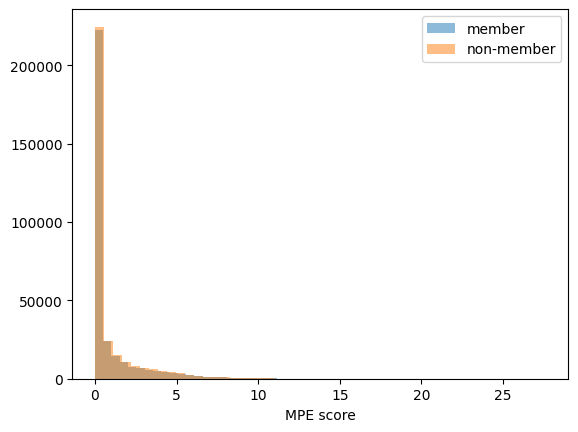

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.hist(results["member scores"].numpy(), bins=50, alpha=0.5, label="member")
ax.hist(results["nonmember scores"].numpy(), bins=50, alpha=0.5, label="non-member")
ax.set_xlabel("MPE score"); ax.legend()
plt.show()


In [9]:
results["member scores"].max()

tensor(25.3680)

In [10]:
from sklearn.metrics import roc_curve 
def mia_mpe_attack_per_class(
        model : torch.nn.Module,
        member_loader: DataLoader,
        nonmember_loader: DataLoader, 
        device : torch.device = torch.device("cpu"),
):
    
    model.to(device)
    model.eval()

    def compute_scores(
            model: torch.nn.Module,  
            loader:DataLoader,
    ):
        mpe_scores = []
        labels = []
        with torch.no_grad():    
            for x,y in loader:
                pred = model(x)
                pred_prob = torch.softmax(pred, dim=1)
                mpe_scores.append(MPE_(pred_prob, y))
                labels.append(y)

        return torch.cat(mpe_scores), torch.cat(labels)


    member_scores, member_labels = compute_scores(model, member_loader)    
    nonmember_scores, nonmember_labels = compute_scores(model, nonmember_loader)    

    n_labels = torch.unique(member_labels)
    best_thresholds = np.zeros(n_labels)
    accs = np.zeros(n_labels)
    tprs = np.zeros(n_labels)

    for label in range(n_labels):
            member_scores_class = member_scores[member_labels == label]
            nonmember_scores_class = member_scores[nonmember_labels == label]
            all_scores = torch.cat([member_scores_class, nonmember_scores_class])
            all_labels = torch.cat([torch.ones(member_scores_class.size()), torch.zeros(nonmember_scores_class.size())])    
            thresholds = np.linspace(all_scores.min(), all_scores.max(), num=100)
            accuracies = [((all_scores <= T) == all_labels).float().mean() for T in thresholds]  
            population_threshold_idx = np.argmax(accuracies)
            best_thresholds[label] = population_threshold_idx
            accs[label] = accuracies[label]

            FPR, TPR, thresh = roc_curve(all_labels, all_scores)
            fpr_optimal_threshold_idx = np.argwhere([FPR <= 0.1])[-1]
            tprs[label] = TPR[fpr_optimal_threshold_idx]

     

    return {
        "MPE_best_accuracy_by_class": accs,
        "best_threshold_by_class": best_thresholds,
        "TPR@0.1FPR": tprs,
    } 
